# Gradient Boosting LambdaRank — Walk-Forward (S1 Equities)

Pooled LightGBM **LambdaRank** on a **slim+near_52w** feature set. Relevance labels =
within-date CS **quintiles** of `fwd_ret_5` (0..4). Early stopping on **NDCG@5** during
fold search only.

**Protocol:** purged expanding walk-forward on research IS (3 folds) → freeze HPs by
selection score + boxplot review → fixed-tree refit on all IS → **one** sealed OS look.

Artifacts use the `s1_lgbm_lambdarank_wf_*` prefix (does not overwrite notebook 03).


## 0. Imports & Config


In [1]:
import os
import sys
import time
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import uniform
from sklearn.model_selection import ParameterSampler

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.report import plot_feature_attrition
from data.processing.cleaner import forward_fill_panel
from models.s1_equities.training_common import (
    LABEL_COL,
    RELEVANCE_COL,
    add_relevance_quintiles,
    attach_scores,
    date_ic_series,
    default_paths,
    drop_nonfinite_labels,
    feature_attrition_summary,
    group_sizes,
    mean_date_ic,
    prepare_s1_week_panel,
    purged_is_walk_forward_folds,
    summarize_fold_trials,
)

PATHS = default_paths(ROOT)
FEATURES_PATH = PATHS["features"]
TRAIN_PANEL_PATH = PATHS["train_panel"]
MODEL_DIR = PATHS["model_dir"]
TEARSHEET_DIR = PATHS["tearsheet_dir"]

PRED_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_wf_predictions.parquet")
IS_MODEL_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_wf_is.txt")
IS_JOBLIB_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_wf_is.joblib")
FOLD_RESULTS_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_wf_fold_results.parquet")
TRIAL_SUMMARY_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_wf_trial_summary.parquet")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TEARSHEET_DIR, exist_ok=True)

# Same linear remove-list; near_52w is force-kept below (nonlinear add-back).
FEATURE_REMOVE = [
    "earnings_yield",
    "smart_beta_mom_126",
    "gdelt_abnormal_attention_5_60",
    "smart_beta_smb_84",
    "val_mom_resid_126_252_10",
    "obv_mom_soft_126_21_20",
    "near_52w_ratio_252_raw",
]
FORCE_KEEP = ["near_52w_ratio_252_raw"]

N_FOLDS = 3
EMBARGO_WEEKS = 1
N_RANDOM_TRIALS = 24
N_ESTIMATORS_CAP = 2000
EARLY_STOPPING_ROUNDS = 70
RANDOM_SEED = 42
ROLLING_IC_WEEKS = 26
SELECTION_PENALTY = 0.5

# Narrow, regularization-leaning search (far fewer DOF than notebook 03).
PARAM_DISTRIBUTIONS = {
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31],
    "learning_rate": [0.01, 0.02],
    "min_child_samples": [100, 200, 350],
    "subsample": uniform(0.6, 0.3),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_lambda": [1.0, 5.0],
}
HP_BOX_COLS = [
    "max_depth",
    "num_leaves",
    "min_child_samples",
    "reg_lambda",
    "learning_rate",
]
HP_ALL_COLS = HP_BOX_COLS + ["subsample", "colsample_bytree"]

print(f"ROOT={ROOT}")
print(f"FEATURES_PATH={FEATURES_PATH}")
print(f"PRED_PATH={PRED_PATH}")
print(f"IS_MODEL_PATH={IS_MODEL_PATH}")
print(f"lightgbm={lgb.__version__}")
print(f"FEATURE_REMOVE={FEATURE_REMOVE}")
print(f"FORCE_KEEP={FORCE_KEEP}")
print(f"N_FOLDS={N_FOLDS}  N_RANDOM_TRIALS={N_RANDOM_TRIALS}")


ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
FEATURES_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
PRED_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_wf_predictions.parquet
IS_MODEL_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_wf_is.txt
lightgbm=4.6.0
FEATURE_REMOVE=['earnings_yield', 'smart_beta_mom_126', 'gdelt_abnormal_attention_5_60', 'smart_beta_smb_84', 'val_mom_resid_126_252_10', 'obv_mom_soft_126_21_20', 'near_52w_ratio_252_raw']
FORCE_KEEP=['near_52w_ratio_252_raw']
N_FOLDS=3  N_RANDOM_TRIALS=24


## 1. Load & feature set

Start from the full engineered week panel, drop the linear slim exclude-list, then
**force-keep** `near_52w_ratio_252_raw` (nonlinear proximity effect).

`filing_clock_expected_until` is already in the linear slim set (not in `FEATURE_REMOVE`).


In [2]:
df, all_feats, prices = prepare_s1_week_panel(FEATURES_PATH, TRAIN_PANEL_PATH)

missing = [c for c in FEATURE_REMOVE if c not in df.columns]
remove_resolved = [c for c in FEATURE_REMOVE if c in df.columns]
if missing:
    print(f"WARNING: FEATURE_REMOVE not in panel (skipped): {missing}")

FEATURE_COLS = [c for c in all_feats if c not in set(remove_resolved)]
for c in FORCE_KEEP:
    if c not in df.columns:
        raise ValueError(f"FORCE_KEEP missing from panel: {c}")
    if c not in FEATURE_COLS:
        FEATURE_COLS.append(c)

print(f"FEATURE_REMOVE resolved ({len(remove_resolved)}): {remove_resolved}")
print(f"FEATURE_COLS kept ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(
    f"rows={len(df):,}  IS weeks={df.loc[df['is_research_is'], 'date'].nunique():,}  "
    f"holdout weeks={df.loc[~df['is_research_is'], 'date'].nunique():,}"
)
display(df.head(3))


FEATURE_REMOVE resolved (7): ['earnings_yield', 'smart_beta_mom_126', 'gdelt_abnormal_attention_5_60', 'smart_beta_smb_84', 'val_mom_resid_126_252_10', 'obv_mom_soft_126_21_20', 'near_52w_ratio_252_raw']
FEATURE_COLS kept (21): ['raw_momentum_252_5', 'smart_residual_mom_189_42', 'rel_downside_beta_252', 'rel_upside_beta_63', 'smart_beta_hml_252', 'downside_beta_42', 'upside_beta_42', 'size_mom_126', 'val_roc_pb_252', 'val_roc_pe_252', 'log_mcap', 'val_mom_dist_252_21', 'gross_profitability', 'filing_clock_expected_until', 'short_flow_ratio', 'market_corr', 'beta_mkt_interact', 'abnormal_volume', 'gdelt_tone_x_attention_21', 'gdelt_attention_5', 'near_52w_ratio_252_raw']
rows=85,279  IS weeks=422  holdout weeks=443


,date,ticker,feature_date,open,high,low,close,volume,fwd_ret_1,fwd_ret_5,...,gross_profitability,filing_clock_expected_until,short_flow_ratio,market_corr,beta_mkt_interact,abnormal_volume,gdelt_tone_x_attention_21,gdelt_attention_5,gdelt_abnormal_attention_5_60,is_research_is
0,2010-01-05,AAPL,2010-01-04,6.424143,6.421146,6.357683,6.406478,493729600.0,-0.001025,-0.025210,...,NaN,27.0,0.439729,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2010-01-05,ABT,2010-01-04,18.082116,18.111994,17.899535,18.078796,10829095.0,-0.009730,0.013402,...,NaN,31.0,0.255644,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2010-01-05,ADBE,2010-01-04,37.040001,37.299999,36.650002,37.090000,4710200.0,0.007829,-0.024298,...,NaN,1.0,0.383420,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. Labels (LambdaRank quintiles — not CS percent-rank)

LightGBM **LambdaRank** needs **integer relevance grades** per group (here: date).
We use within-date CS **quintiles** of `fwd_ret_5` → integers 0..4 (4 = best).

**Continuous CS percent-rank of `fwd_ret_5` cannot be used as a LambdaRank label**
(that target belongs with RMSE / Ridge). Evaluation still uses Spearman IC vs
`fwd_ret_5`.


In [3]:
df = drop_nonfinite_labels(df, [LABEL_COL])
df = add_relevance_quintiles(df)
df = df.loc[df[RELEVANCE_COL].notna()].sort_values(["date", "ticker"]).reset_index(drop=True)

print(f"rows after label filter={len(df):,}")
print(f"relevance value counts:\n{df[RELEVANCE_COL].value_counts().sort_index()}")
print(f"NaN features any-row (pre-ffill)={df[FEATURE_COLS].isna().any(axis=1).mean():.2%}")


rows after label filter=85,179
relevance value counts:
relevance
0.0    17280
1.0    16880
2.0    16859
3.0    16880
4.0    17280
Name: count, dtype: int64
NaN features any-row (pre-ffill)=93.64%


## 3. Forward-fill + missingness (no complete-case drop)

Unlimited within-ticker ffill on model features (same helper as linear slim).
**We do not drop incomplete rows** — residual NaNs stay for LightGBM missing splits.

The attrition plot shows how many names *would* be dropped under complete-case rules
and which features bind (same style as the OOS tearsheet).


Per-feature NaN % before / after unlimited ffill:


,nan_pct_before,nan_pct_after_ffill,pp_recovered
gdelt_tone_x_attention_21,42.90,36.70,6.20
gross_profitability,39.93,39.93,0.00
gdelt_attention_5,39.84,34.20,5.64
val_roc_pe_252,37.93,12.30,25.63
filing_clock_expected_until,34.63,5.74,28.89
downside_beta_42,31.17,1.41,29.76
short_flow_ratio,30.31,0.82,29.49
smart_residual_mom_189_42,29.35,29.35,0.00
val_roc_pb_252,28.95,18.32,10.63
val_mom_dist_252_21,26.49,16.35,10.14


Any-row NaN after ffill=58.81%  (rows kept=85,179 — no complete-case drop)
Attrition by_date describe (complete-case hypothetical):


,n_candidates,n_complete,n_dropped
count,864.000000,864.000000,864.000000
mean,98.586806,40.604167,57.982639
std,1.477326,28.559763,29.783785
min,97.000000,0.000000,29.000000
25%,97.000000,0.000000,32.000000
50%,100.000000,50.000000,50.000000
75%,100.000000,65.000000,100.000000
max,100.000000,68.000000,100.000000


Total blame (share of rows NaN on feature):


,total_blame
gross_profitability,0.399277
gdelt_tone_x_attention_21,0.367015
gdelt_attention_5,0.341986
smart_residual_mom_189_42,0.293500
smart_beta_hml_252,0.262976
val_roc_pb_252,0.183226
val_mom_dist_252_21,0.163456
val_roc_pe_252,0.122976
size_mom_126,0.112082
market_corr,0.062222


Exclusive blame (only-NaN feature among dropped rows):


,exclusive_blame
gross_profitability,0.268439
gdelt_tone_x_attention_21,0.032217
val_roc_pb_252,0.013554
short_flow_ratio,0.003074
val_roc_pe_252,0.001497
smart_beta_hml_252,0.000000
rel_upside_beta_63,0.000000
rel_downside_beta_252,0.000000
smart_residual_mom_189_42,0.000000
raw_momentum_252_5,0.000000


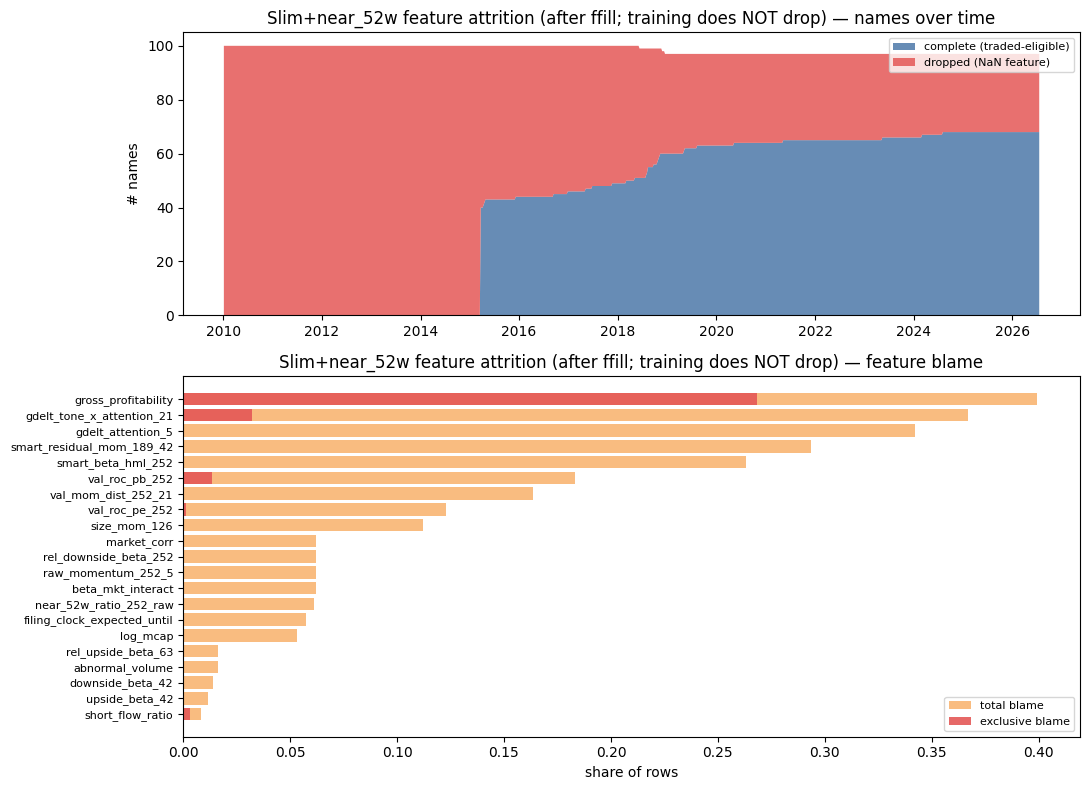

In [4]:
nan_before = df[FEATURE_COLS].isna().mean().sort_values(ascending=False)
df = forward_fill_panel(df, columns=FEATURE_COLS, limit=None)
nan_after = df[FEATURE_COLS].isna().mean().sort_values(ascending=False)

cov = pd.DataFrame(
    {
        "nan_pct_before": (100 * nan_before).round(2),
        "nan_pct_after_ffill": (100 * nan_after.reindex(nan_before.index)).round(2),
    }
)
cov["pp_recovered"] = (cov["nan_pct_before"] - cov["nan_pct_after_ffill"]).round(2)
print("Per-feature NaN % before / after unlimited ffill:")
display(cov)

print(
    f"Any-row NaN after ffill={df[FEATURE_COLS].isna().any(axis=1).mean():.2%}  "
    f"(rows kept={len(df):,} — no complete-case drop)"
)

# Already ffilled: pass ffill=False so the diagnostic does not ffill twice.
attrition_summary = feature_attrition_summary(
    df, FEATURE_COLS, ffill=False
)
print("Attrition by_date describe (complete-case hypothetical):")
display(attrition_summary["by_date"].describe())
print("Total blame (share of rows NaN on feature):")
display(attrition_summary["total_blame"].to_frame())
print("Exclusive blame (only-NaN feature among dropped rows):")
display(attrition_summary["exclusive_blame"].to_frame())

fig = plot_feature_attrition(
    attrition_summary,
    title="Slim+near_52w feature attrition (after ffill; training does NOT drop)",
)
plt.show()


## 4. Walk-forward folds (IS only)

Three expanding purged folds on research-IS week-starts. OS holdout stays sealed
(`date > is_end` and not research IS). Embargo = 1 week between train and val.


In [6]:
is_dates = pd.DatetimeIndex(
    df.loc[df["is_research_is"], "date"].drop_duplicates().sort_values()
)
is_end = is_dates.max()
holdout_df = df.loc[(~df["is_research_is"]) & (df["date"] > is_end)].sort_values(
    ["date", "ticker"]
)

folds = purged_is_walk_forward_folds(
    is_dates, n_folds=N_FOLDS, embargo_weeks=EMBARGO_WEEKS
)

fold_rows = []
for f in folds:
    fold_rows.append(
        {
            "fold_id": f.fold_id,
            "train_start": f.train_dates.min().date(),
            "train_end": f.train_dates.max().date(),
            "n_train_weeks": len(f.train_dates),
            "embargo": list(f.embargo_dates.date),
            "val_start": f.val_dates.min().date(),
            "val_end": f.val_dates.max().date(),
            "n_val_weeks": len(f.val_dates),
        }
    )
fold_table = pd.DataFrame(fold_rows).set_index("fold_id")
display(fold_table)

print(
    f"IS weeks={len(is_dates)}  is_end={is_end.date()}  "
    f"OS holdout weeks={holdout_df['date'].nunique()}  "
    f"({holdout_df['date'].min().date() if len(holdout_df) else 'n/a'} -> "
    f"{holdout_df['date'].max().date() if len(holdout_df) else 'n/a'})"
)


,train_start,train_end,n_train_weeks,embargo,val_start,val_end,n_val_weeks
fold_id,,,,,,,
1,2015-01-05,2016-12-27,104,[2017-01-03],2017-01-09,2019-01-14,106
2,2015-01-05,2019-01-07,210,[2019-01-14],2019-01-22,2021-01-19,105
3,2015-01-05,2021-01-11,315,[2021-01-19],2021-01-25,2023-01-30,106


IS weeks=422  is_end=2023-01-30  OS holdout weeks=181  (2023-02-06 -> 2026-07-20)


## 5. HP search (trial × fold)

For each of ~24 parameter draws and each fold: fit LambdaRank on fold-train,
early-stop on fold-val (NDCG@5), score **mean date Spearman IC** on fold-val.

Outputs:

- `fold_results` — long frame (plotting source)
- `trial_summary` — one row per trial with selection score
  `mean_ic - 0.5 * std_ic`


In [7]:
def fit_lambdarank(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame | None,
    feature_cols: list,
    params: dict,
    *,
    num_boost_round: int = N_ESTIMATORS_CAP,
    early_stopping_rounds: int | None = EARLY_STOPPING_ROUNDS,
    verbose_eval: int = 0,
) -> lgb.Booster:
    """Fit LambdaRank. Early-stop on NDCG@5 when val_frame is provided."""
    dtrain = lgb.Dataset(
        train_frame[feature_cols],
        label=train_frame[RELEVANCE_COL].astype(int),
        group=group_sizes(train_frame),
        free_raw_data=False,
    )
    p = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "eval_at": [5],
        "verbosity": -1,
        "seed": RANDOM_SEED,
        "bagging_freq": 1,
        **params,
    }
    callbacks = [lgb.log_evaluation(period=verbose_eval)]
    if early_stopping_rounds is not None and val_frame is not None and len(val_frame):
        dval = lgb.Dataset(
            val_frame[feature_cols],
            label=val_frame[RELEVANCE_COL].astype(int),
            group=group_sizes(val_frame),
            reference=dtrain,
            free_raw_data=False,
        )
        callbacks.insert(
            0, lgb.early_stopping(early_stopping_rounds, verbose=False)
        )
        return lgb.train(
            p,
            dtrain,
            num_boost_round=num_boost_round,
            valid_sets=[dval],
            valid_names=["valid"],
            callbacks=callbacks,
        )
    return lgb.train(
        p,
        dtrain,
        num_boost_round=num_boost_round,
        callbacks=callbacks,
    )


def predict_scores(
    booster: lgb.Booster, frame: pd.DataFrame, feature_cols: list
) -> pd.DataFrame:
    return attach_scores(frame, booster.predict(frame[feature_cols]))


In [8]:
sampler = list(
    ParameterSampler(
        PARAM_DISTRIBUTIONS,
        n_iter=N_RANDOM_TRIALS,
        random_state=RANDOM_SEED,
    )
)

fold_records: list[dict] = []
t0 = time.time()

for trial_id, raw in enumerate(sampler):
    params = {
        "max_depth": int(raw["max_depth"]),
        "num_leaves": int(raw["num_leaves"]),
        "learning_rate": float(raw["learning_rate"]),
        "min_child_samples": int(raw["min_child_samples"]),
        "subsample": float(raw["subsample"]),
        "colsample_bytree": float(raw["colsample_bytree"]),
        "reg_lambda": float(raw["reg_lambda"]),
    }
    fold_ics = []
    fold_trees = []
    for f in folds:
        train_df = df.loc[df["date"].isin(f.train_dates)].sort_values(
            ["date", "ticker"]
        )
        val_df = df.loc[df["date"].isin(f.val_dates)].sort_values(
            ["date", "ticker"]
        )
        booster = fit_lambdarank(train_df, val_df, FEATURE_COLS, params)
        preds_val = predict_scores(booster, val_df, FEATURE_COLS)
        sm = mean_date_ic(preds_val)
        fold_ics.append(sm["mean_ic"])
        fold_trees.append(int(booster.best_iteration or 1))
        fold_records.append(
            {
                "trial_id": trial_id,
                "fold_id": f"Fold {f.fold_id}",
                "fold_num": f.fold_id,
                "fold_ic": sm["mean_ic"],
                "fold_icir": sm["icir"],
                "best_iteration": int(booster.best_iteration or 1),
                **params,
            }
        )
    print(
        f"trial {trial_id:02d}/{N_RANDOM_TRIALS - 1}  "
        f"mean_ic={np.nanmean(fold_ics):.4f}  "
        f"worst={np.nanmin(fold_ics):.4f}  "
        f"trees~{int(np.median(fold_trees))}  "
        f"depth={params['max_depth']} leaves={params['num_leaves']} "
        f"lr={params['learning_rate']} min_child={params['min_child_samples']}"
    )

fold_results = pd.DataFrame(fold_records)
trial_summary = summarize_fold_trials(
    fold_results,
    hp_cols=HP_ALL_COLS,
    penalty=SELECTION_PENALTY,
)

fold_results.to_parquet(FOLD_RESULTS_PATH, index=False)
trial_summary.to_parquet(TRIAL_SUMMARY_PATH, index=False)
print(f"\nSearch done in {(time.time() - t0) / 60:.1f} min")
print(f"Saved {FOLD_RESULTS_PATH}")
print(f"Saved {TRIAL_SUMMARY_PATH}")
display(trial_summary.head(10))


trial 00/23  mean_ic=0.0213  worst=0.0140  trees~20  depth=5 leaves=31 lr=0.01 min_child=350
trial 01/23  mean_ic=0.0155  worst=0.0044  trees~3  depth=5 leaves=31 lr=0.01 min_child=350
trial 02/23  mean_ic=0.0191  worst=0.0106  trees~39  depth=3 leaves=31 lr=0.02 min_child=200
trial 03/23  mean_ic=0.0199  worst=0.0156  trees~4  depth=3 leaves=31 lr=0.02 min_child=100
trial 04/23  mean_ic=0.0254  worst=0.0220  trees~49  depth=5 leaves=15 lr=0.01 min_child=350
trial 05/23  mean_ic=0.0251  worst=0.0237  trees~30  depth=4 leaves=15 lr=0.01 min_child=200
trial 06/23  mean_ic=0.0231  worst=0.0141  trees~20  depth=3 leaves=15 lr=0.02 min_child=350
trial 07/23  mean_ic=0.0247  worst=0.0124  trees~46  depth=3 leaves=31 lr=0.02 min_child=200
trial 08/23  mean_ic=0.0313  worst=0.0225  trees~11  depth=5 leaves=31 lr=0.02 min_child=350
trial 09/23  mean_ic=0.0239  worst=0.0165  trees~24  depth=4 leaves=31 lr=0.01 min_child=200
trial 10/23  mean_ic=0.0198  worst=0.0188  trees~49  depth=5 leaves=31 l

,trial_id,mean_ic,std_ic,worst_ic,median_best_iteration,selection_score,n_folds,max_depth,num_leaves,min_child_samples,reg_lambda,learning_rate,subsample,colsample_bytree
0,8,0.031285,0.009668,0.022458,11,0.026451,3,5,31,350,1.0,0.02,0.849958,0.639069
1,5,0.025120,0.001656,0.023747,30,0.024292,3,4,15,200,5.0,0.01,0.659902,0.989502
2,4,0.025401,0.002986,0.021961,49,0.023908,3,5,15,350,5.0,0.01,0.614000,0.772778
3,16,0.026196,0.005933,0.019714,97,0.023230,3,4,31,100,1.0,0.01,0.693295,0.965984
4,23,0.026032,0.006660,0.018348,84,0.022702,3,3,31,200,5.0,0.01,0.665532,0.923248
5,17,0.024332,0.006016,0.018419,17,0.021324,3,4,15,350,1.0,0.01,0.714878,0.730073
6,12,0.024639,0.006945,0.017809,36,0.021167,3,3,31,100,1.0,0.02,0.848621,0.618091
7,21,0.023449,0.006604,0.015969,29,0.020147,3,5,15,100,1.0,0.01,0.660918,0.963027
8,15,0.023869,0.007859,0.017283,27,0.019939,3,5,31,100,1.0,0.01,0.795323,0.891603
9,9,0.023895,0.008283,0.016541,24,0.019754,3,4,31,200,5.0,0.01,0.662382,0.669346


## 6. Interpret & pick

Boxplots **complement** the selection-score leaderboard — they do not replace it.

**Y-axis** = fold validation mean date IC (`fold_ic`; higher = better).
Do not chase NDCG training loss here.


### 6.2 Per-hyperparameter fold-hue boxplots

For each discrete HP: **X** = HP value, **Y** = `fold_ic`, **hue** = fold
(one colored box per fold at each x-value).


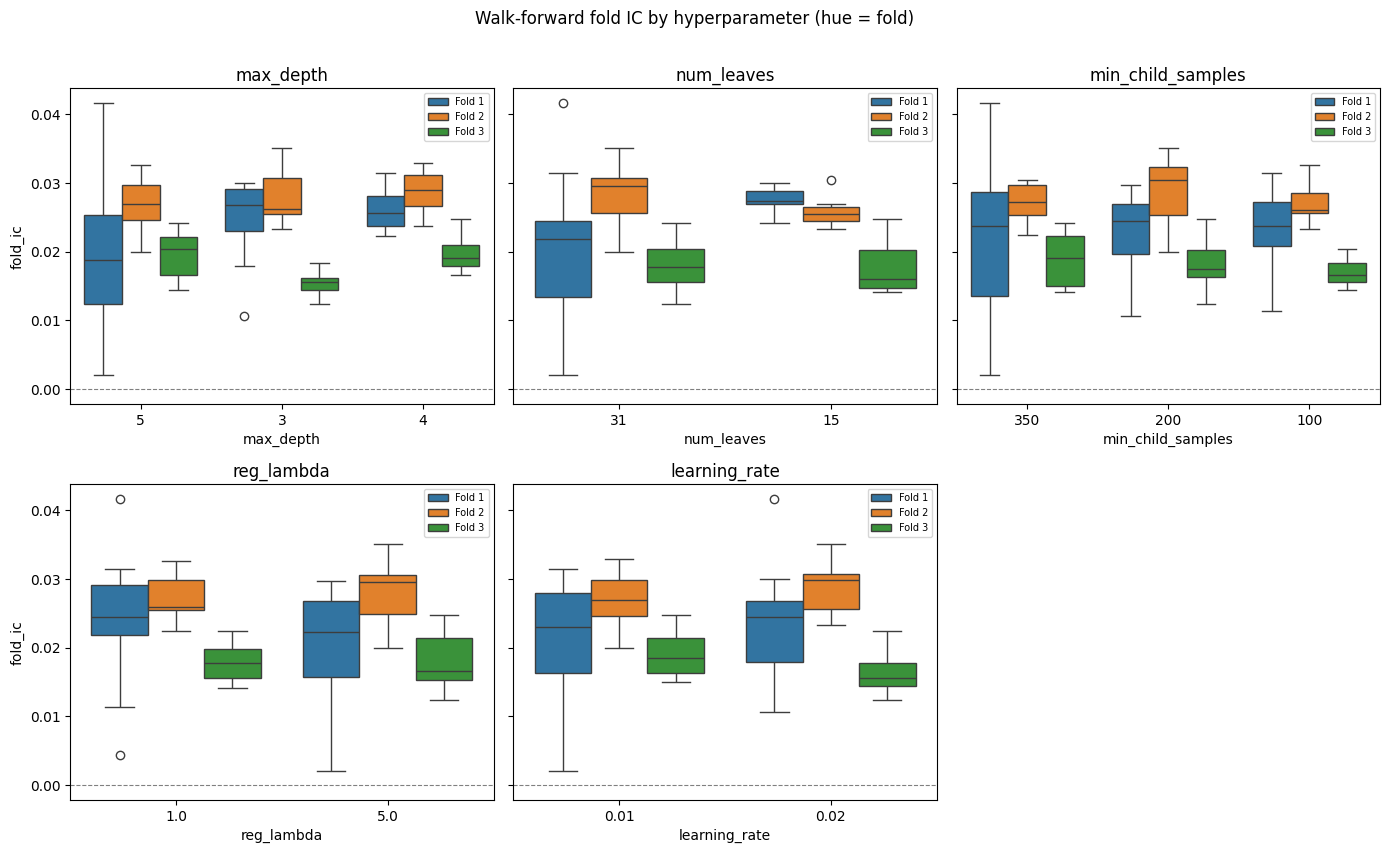

In [9]:
n_hp = len(HP_BOX_COLS)
ncols = 3
nrows = int(np.ceil(n_hp / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), sharey=True)
axes = np.asarray(axes).reshape(-1)

for ax, col in zip(axes, HP_BOX_COLS):
    plot_df = fold_results.copy()
    plot_df[col] = plot_df[col].astype(str)
    sns.boxplot(
        data=plot_df,
        x=col,
        y="fold_ic",
        hue="fold_id",
        ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("fold_ic")
    ax.axhline(0.0, color="gray", lw=0.8, ls="--")
    ax.legend(fontsize=7, title="")

for ax in axes[len(HP_BOX_COLS) :]:
    ax.axis("off")

fig.suptitle("Walk-forward fold IC by hyperparameter (hue = fold)", y=1.01)
fig.tight_layout()
plt.show()


**How to read these boxes (priority order)**

1. **Level (mean / median of the box) — most important.** Prefer HP values whose boxes sit higher on `fold_ic`. A higher central box usually beats a flashy upper whisker.
2. **Cross-fold agreement — second.** At a given x-value, the three fold-colored boxes should be close. Large gaps between folds = regime-specific luck; prefer the value where Fold 1/2/3 boxes overlap more, even if its peak is slightly lower.
3. **Worst fold — third.** Check the lowest of the three boxes (and §6.3 for which fold is hard). Do not pick a setting that only wins the easy fold(s).
4. **Spread within a fold (IQR / box height) — fourth.** Tighter boxes = more stable across trials that share that HP value. Wide boxes = noisy; treat as weak evidence.
5. **Skew and outliers (whiskers / points) — least important for picking.** A long upper whisker or a few high outlier points is **not** a reason to prefer that HP; that is often one lucky trial. A long lower whisker / low outliers is a mild warning (downside risk), not a veto if level + fold agreement are good.
6. **Do not optimize whisker max.** Ignore “which box reaches highest”; that is selection bias. Prefer high **center**, good **fold alignment**, acceptable **worst fold**.


### 6.3 Fold-vs-fold overview

How hard is each regime in general (pooling all trials)?


,fold_id,mean,std,median,n
0,Fold 1,0.022050,0.009124,0.023746,24
1,Fold 2,0.027574,0.003739,0.027189,24
2,Fold 3,0.018058,0.003415,0.017546,24


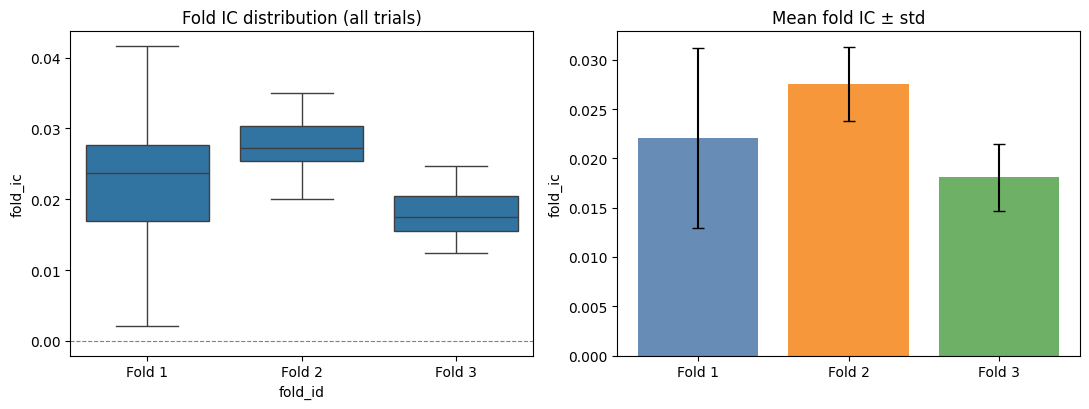

If one fold is systematically harder, prefer HPs that do not collapse there (use worst_ic / fold-hue boxes), not only winners on easy folds.


In [10]:
fold_stats = (
    fold_results.groupby("fold_id", sort=False)["fold_ic"]
    .agg(mean="mean", std="std", median="median", n="count")
    .reset_index()
)
display(fold_stats)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(data=fold_results, x="fold_id", y="fold_ic", ax=axes[0])
axes[0].axhline(0.0, color="gray", lw=0.8, ls="--")
axes[0].set_title("Fold IC distribution (all trials)")
axes[0].set_ylabel("fold_ic")

axes[1].bar(
    fold_stats["fold_id"],
    fold_stats["mean"],
    yerr=fold_stats["std"].fillna(0.0),
    color=["#4C78A8", "#F58518", "#54A24B"][: len(fold_stats)],
    alpha=0.85,
    capsize=4,
)
axes[1].axhline(0.0, color="gray", lw=0.8, ls="--")
axes[1].set_title("Mean fold IC ± std")
axes[1].set_ylabel("fold_ic")
fig.tight_layout()
plt.show()

print(
    "If one fold is systematically harder, prefer HPs that do not collapse there "
    "(use worst_ic / fold-hue boxes), not only winners on easy folds."
)


### 6.4 Leaderboard, scatter, top-k fold profile


Leaderboard (selection_score = mean_ic - 0.5 * std_ic):


,trial_id,mean_ic,std_ic,worst_ic,median_best_iteration,selection_score,n_folds,max_depth,num_leaves,min_child_samples,reg_lambda,learning_rate,subsample,colsample_bytree
0,8,0.031285,0.009668,0.022458,11,0.026451,3,5,31,350,1.0,0.02,0.849958,0.639069
1,5,0.025120,0.001656,0.023747,30,0.024292,3,4,15,200,5.0,0.01,0.659902,0.989502
2,4,0.025401,0.002986,0.021961,49,0.023908,3,5,15,350,5.0,0.01,0.614000,0.772778
3,16,0.026196,0.005933,0.019714,97,0.023230,3,4,31,100,1.0,0.01,0.693295,0.965984
4,23,0.026032,0.006660,0.018348,84,0.022702,3,3,31,200,5.0,0.01,0.665532,0.923248
5,17,0.024332,0.006016,0.018419,17,0.021324,3,4,15,350,1.0,0.01,0.714878,0.730073
6,12,0.024639,0.006945,0.017809,36,0.021167,3,3,31,100,1.0,0.02,0.848621,0.618091
7,21,0.023449,0.006604,0.015969,29,0.020147,3,5,15,100,1.0,0.01,0.660918,0.963027
8,15,0.023869,0.007859,0.017283,27,0.019939,3,5,31,100,1.0,0.01,0.795323,0.891603
9,9,0.023895,0.008283,0.016541,24,0.019754,3,4,31,200,5.0,0.01,0.662382,0.669346


Top-5 trials — per-fold IC:


,Fold 1,Fold 2,Fold 3,selection_score,mean_ic,std_ic,worst_ic,median_best_iteration
trial_id,,,,,,,,
8,0.041617,0.029779,0.022458,0.026451,0.031285,0.009668,0.022458,11
5,0.026959,0.023747,0.024654,0.024292,0.025120,0.001656,0.023747,30
4,0.027323,0.026919,0.021961,0.023908,0.025401,0.002986,0.021961,49
16,0.031356,0.027519,0.019714,0.023230,0.026196,0.005933,0.019714,97
23,0.029609,0.030140,0.018348,0.022702,0.026032,0.006660,0.018348,84


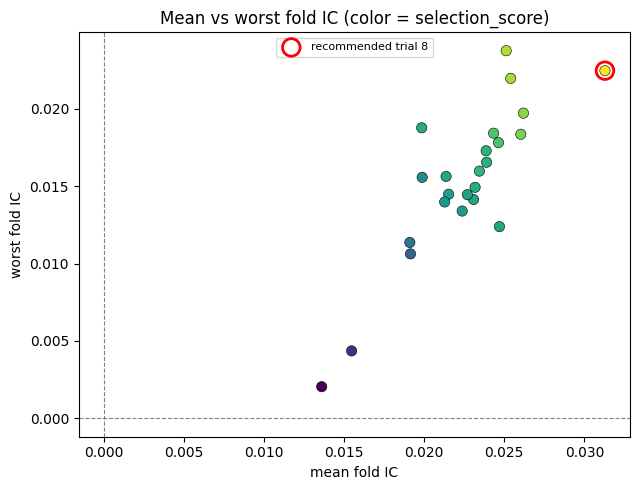

In [11]:
leaderboard = trial_summary.sort_values(
    ["selection_score", "mean_ic", "worst_ic"], ascending=False
).reset_index(drop=True)
print("Leaderboard (selection_score = mean_ic - 0.5 * std_ic):")
display(leaderboard.head(12))

top5 = leaderboard.head(5)["trial_id"].tolist()
profile = (
    fold_results.loc[fold_results["trial_id"].isin(top5)]
    .pivot_table(index="trial_id", columns="fold_id", values="fold_ic")
    .reindex(top5)
)
profile = profile.join(
    leaderboard.set_index("trial_id")[
        ["selection_score", "mean_ic", "std_ic", "worst_ic", "median_best_iteration"]
    ]
)
print("Top-5 trials — per-fold IC:")
display(profile)

rec_trial = int(leaderboard.iloc[0]["trial_id"])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(
    trial_summary["mean_ic"],
    trial_summary["worst_ic"],
    c=trial_summary["selection_score"],
    cmap="viridis",
    s=55,
    edgecolor="k",
    linewidths=0.4,
)
rec = trial_summary.loc[trial_summary["trial_id"] == rec_trial].iloc[0]
ax.scatter(
    [rec["mean_ic"]],
    [rec["worst_ic"]],
    s=160,
    facecolors="none",
    edgecolors="red",
    linewidths=2.0,
    label=f"recommended trial {rec_trial}",
)
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.axvline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("mean fold IC")
ax.set_ylabel("worst fold IC")
ax.set_title("Mean vs worst fold IC (color = selection_score)")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


### 6.5 How to pick — end-to-end checklist

1. Look at **§6.3** — note which fold is hardest.
2. Look at **§6.2** with the reading order above — for depth / leaves / min_child / λ / lr, shortlist values with high centers and aligned fold colors.
3. Confirm the **leaderboard** top row is not a lonely max with poor `worst_ic` or huge `std_ic`.
4. Accept `RECOMMENDED_PARAMS` + `N_TREES` below, **or** set overrides in the next cell before freeze.

Auto-recommend rule: argmax of `mean_ic - 0.5 * std_ic`. Use boxplots to **veto fragile winners**, not to chase upper outliers.


In [20]:
best_row = leaderboard.iloc[0]
#RECOMMENDED_PARAMS = {
#    "max_depth": int(best_row["max_depth"]),
#    "num_leaves": int(best_row["num_leaves"]),
#    "learning_rate": float(best_row["learning_rate"]),
#    "min_child_samples": int(best_row["min_child_samples"]),
#    "subsample": float(best_row["subsample"]),
#    "colsample_bytree": float(best_row["colsample_bytree"]),
#    "reg_lambda": float(best_row["reg_lambda"]),
#}
RECOMMENDED_PARAMS = {
    "max_depth": 4,
    "num_leaves": 31,
    "learning_rate": 0.02,
    "min_child_samples": 200,
    "subsample": 0.85,
    "colsample_bytree": 0.6,
    "reg_lambda": 1.0,
}
RECOMMENDED_N_TREES = int(best_row["median_best_iteration"])
RECOMMENDED_TRIAL_ID = int(best_row["trial_id"])

print(f"RECOMMENDED_TRIAL_ID={RECOMMENDED_TRIAL_ID}")
print(f"selection_score={best_row['selection_score']:.4f}")
print(f"mean_ic={best_row['mean_ic']:.4f}  std_ic={best_row['std_ic']:.4f}  "
      f"worst_ic={best_row['worst_ic']:.4f}")
print(f"RECOMMENDED_N_TREES={RECOMMENDED_N_TREES}")
print("RECOMMENDED_PARAMS:")
for k, v in RECOMMENDED_PARAMS.items():
    print(f"  {k}={v}")

# --- Manual override (leave None to accept recommendation) ---
OVERRIDE_PARAMS = None  # e.g. dict matching RECOMMENDED_PARAMS keys
OVERRIDE_N_TREES = None  # e.g. 80

BEST_PARAMS = dict(OVERRIDE_PARAMS) if OVERRIDE_PARAMS is not None else dict(RECOMMENDED_PARAMS)
N_TREES = int(OVERRIDE_N_TREES) if OVERRIDE_N_TREES is not None else int(RECOMMENDED_N_TREES)

print("\nFROZEN for refit:")
print(f"  N_TREES={N_TREES}")
for k, v in BEST_PARAMS.items():
    print(f"  {k}={v}")


RECOMMENDED_TRIAL_ID=8
selection_score=0.0265
mean_ic=0.0313  std_ic=0.0097  worst_ic=0.0225
RECOMMENDED_N_TREES=11
RECOMMENDED_PARAMS:
  max_depth=4
  num_leaves=31
  learning_rate=0.02
  min_child_samples=200
  subsample=0.85
  colsample_bytree=0.6
  reg_lambda=1.0

FROZEN for refit:
  N_TREES=11
  max_depth=4
  num_leaves=31
  learning_rate=0.02
  min_child_samples=200
  subsample=0.85
  colsample_bytree=0.6
  reg_lambda=1.0


## 7. Freeze & refit (all IS, fixed trees)

Refit on **all research-IS** week-starts with **fixed** `num_boost_round=N_TREES`
(no early stopping, no OS in the fit). Then score the full panel for diagnostics.


In [21]:
is_df = df.loc[df["is_research_is"]].sort_values(["date", "ticker"])
# Need a tiny val stub only if early stopping were on; here we pass None.
model = fit_lambdarank(
    is_df,
    None,
    FEATURE_COLS,
    BEST_PARAMS,
    num_boost_round=N_TREES,
    early_stopping_rounds=None,
    verbose_eval=50,
)

preds = predict_scores(model, df, FEATURE_COLS)
if "feature_date" in df.columns:
    preds = preds.merge(
        df[["date", "ticker", "feature_date"]],
        on=["date", "ticker"],
        how="left",
    )

model.save_model(IS_MODEL_PATH)
joblib.dump(
    {
        "best_params": BEST_PARAMS,
        "n_trees": N_TREES,
        "feature_cols": FEATURE_COLS,
        "recommended_trial_id": RECOMMENDED_TRIAL_ID,
        "selection_penalty": SELECTION_PENALTY,
        "n_folds": N_FOLDS,
        "force_keep": FORCE_KEEP,
        "feature_remove": remove_resolved,
    },
    IS_JOBLIB_PATH,
)
preds.to_parquet(PRED_PATH, index=False)

print(f"Saved model: {IS_MODEL_PATH}")
print(f"Saved joblib: {IS_JOBLIB_PATH}")
print(f"Saved predictions: {PRED_PATH}")
print(f"num_trees used={N_TREES}  (booster trees={model.num_trees()})")


Saved model: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_wf_is.txt
Saved joblib: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_wf_is.joblib
Saved predictions: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_wf_predictions.parquet
num_trees used=11  (booster trees=11)


## 8. Sealed OS once

Score IS vs sealed OS holdout. **Do not** change HPs / features / NaN policy after
looking at these numbers. Linear slim OS reference ~ mean IC **0.033**.

Honest validation for HPs lives in sections 5-6 (fold_results). After the all-IS refit,
IS segment ICs below are **optimistic** (those weeks were in the final training
set). The decision metric is **OS holdout only**.

If GBM loses OS: keep linear as production and document the WF evidence - do not retune on OS.


,mean_ic,icir,n_dates
segment,,,
IS train (non-val weeks),0.027371,0.132820,105
IS val folds (pooled),0.046226,0.214571,317
IS all,0.041535,0.194945,422
OS holdout,0.004105,0.021719,181


IS all IC=0.0415 ICIR=0.195  |  OS holdout IC=0.0041 ICIR=0.022
Linear slim OS reference (notebook 05): mean_ic≈0.0325  ICIR≈0.128


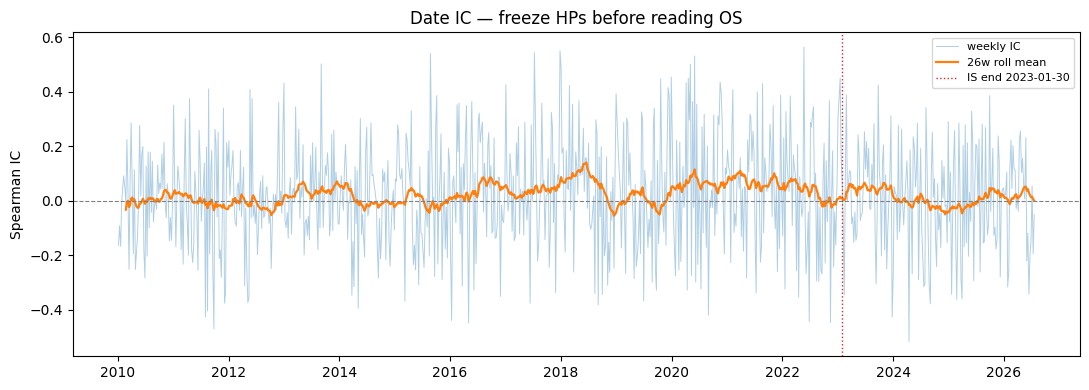

In [22]:
is_preds = preds.loc[preds["is_research_is"]]
os_preds = preds.loc[(~preds["is_research_is"]) & (preds["date"] > is_end)]

# Pooled IS fold-val windows (post-refit IS metrics are in-sample / optimistic).
val_dates_all = folds[0].val_dates
for f in folds[1:]:
    val_dates_all = val_dates_all.union(f.val_dates)
train_dates_all = is_dates.difference(val_dates_all)

rows = []
for name, part in (
    ("IS train (non-val weeks)", preds.loc[preds["date"].isin(train_dates_all)]),
    ("IS val folds (pooled)", preds.loc[preds["date"].isin(val_dates_all)]),
    ("IS all", is_preds),
    ("OS holdout", os_preds),
):
    sm = mean_date_ic(part)
    rows.append(
        {
            "segment": name,
            "mean_ic": sm["mean_ic"],
            "icir": sm["icir"],
            "n_dates": sm["n"],
        }
    )
ic_compare = pd.DataFrame(rows).set_index("segment")
display(ic_compare)

ho = ic_compare.loc["OS holdout"]
is_all = ic_compare.loc["IS all"]
print(
    f"IS all IC={is_all['mean_ic']:.4f} ICIR={is_all['icir']:.3f}  |  "
    f"OS holdout IC={ho['mean_ic']:.4f} ICIR={ho['icir']:.3f}"
)
print("Linear slim OS reference (notebook 05): mean_ic≈0.0325  ICIR≈0.128")

ics = date_ic_series(preds).dropna().sort_index()
roll = ics.rolling(ROLLING_IC_WEEKS, min_periods=max(5, ROLLING_IC_WEEKS // 3)).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ics.index, ics.values, lw=0.7, alpha=0.35, label="weekly IC")
ax.plot(roll.index, roll.values, lw=1.6, label=f"{ROLLING_IC_WEEKS}w roll mean")
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.axvline(is_end, color="C3", lw=1.0, ls=":", label=f"IS end {is_end.date()}")
ax.set_title("Date IC — freeze HPs before reading OS")
ax.set_ylabel("Spearman IC")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()
